
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


12473 corpus
type
Plat principal    46.52
Dessert           30.16
Entrée            23.32
Name: proportion, dtype: float64 

difficulte
Très facile              50.23
Facile                   41.49
Moyennement difficile     7.70
Difficile                 0.58
Name: proportion, dtype: float64 

cout
Bon marché    67.70
Moyen         29.06
Assez Cher     3.24
Name: proportion, dtype: float64 

 Recipe name :Bûche à la truite fumée (7ème rencontre)
 Length: 139
 Frequent word :de
 Class: Entrée
[('title_length', 1.0, 9.0, 2.62), ('recipe_length', -21.0, 251.0, 4.31), ('ingredients_length', -3.0, 93.0, 3.51), ('number_of_ingredient', 1.0, 17.0, 2.57)]
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


KeyboardInterrupt: 

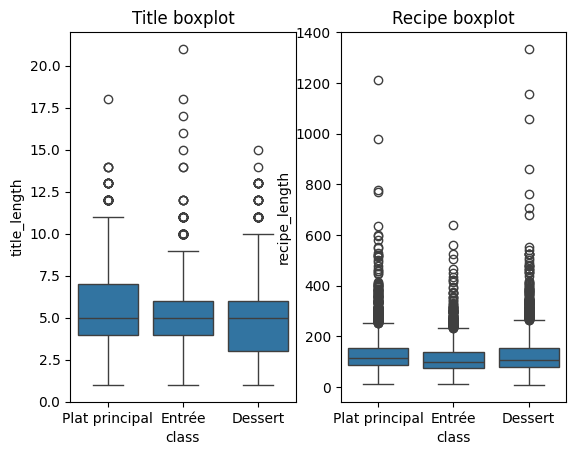

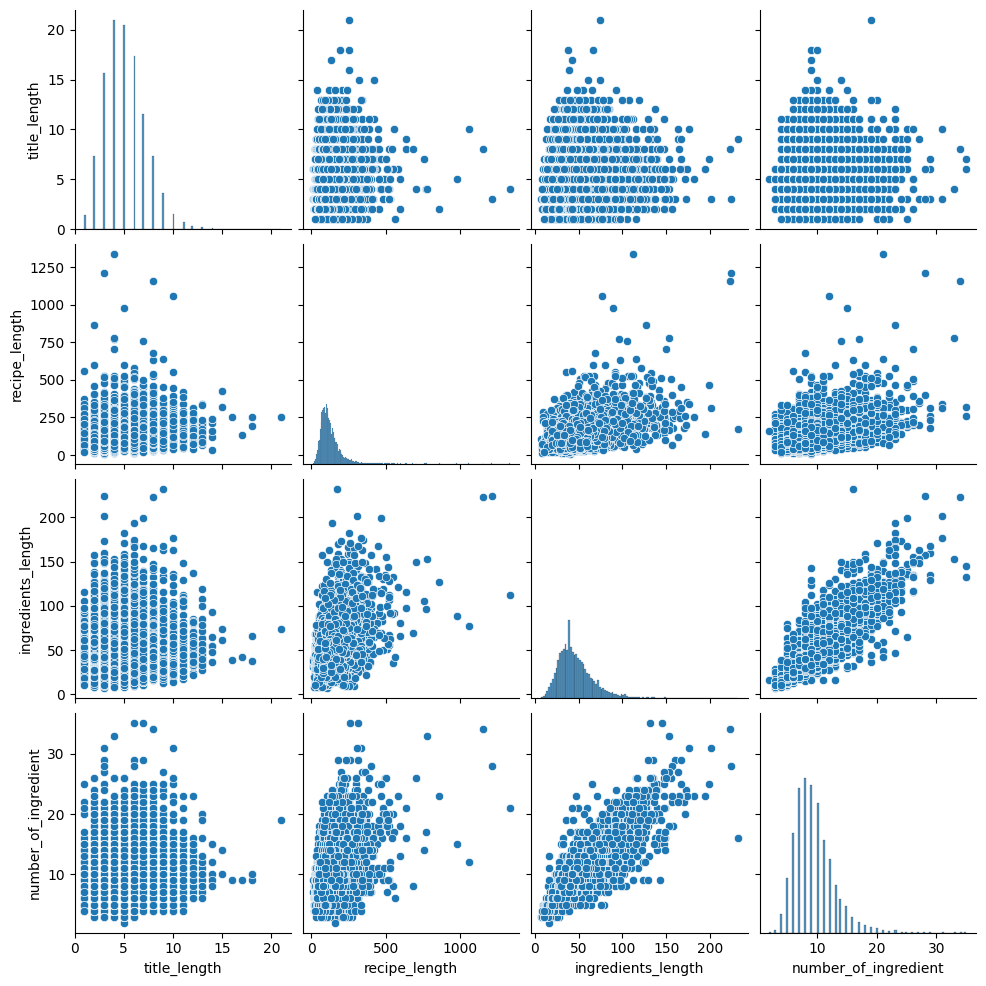

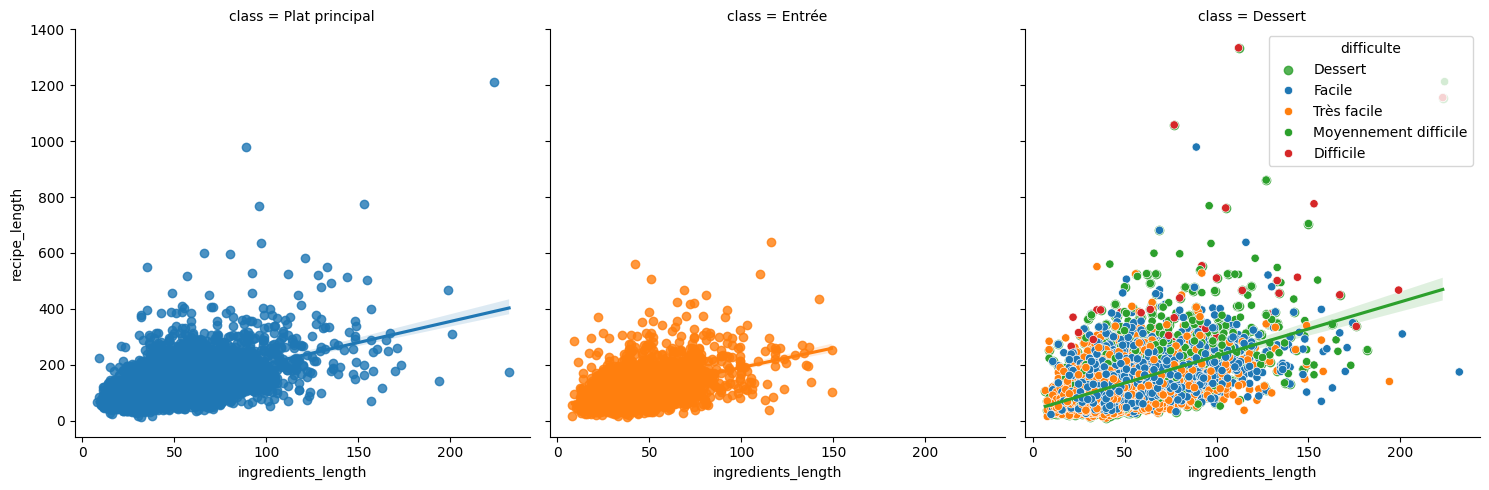

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
from etl_step import sentence_length, sentence_freq_word, count_ingredient

In [69]:
train = pd.read_csv("../data/clean_train.csv", sep=',')
test = pd.read_csv("../data/clean_test.csv", sep=',')

In [70]:
X = train["clean_recette"] + " " + train["clean_ingredients"]
y = train["type"]
X_test = test["clean_recette"]+ " " + test["clean_ingredients"]
y_test = test["type"]

In [71]:
train.head(2)

,titre,type,difficulte,cout,ingredients,recette,clean_recette,clean_ingredients
0,"Feuilleté de saumon et de poireau, sauce aux c...",Plat principal,Facile,Moyen,- 1 gros pavé de saumon - 100 g de crevettes d...,Couper finement le blanc et un peu de vert des...,couper finement blanc vert poireau rondell épl...,1 gros pavé saumon 100 gramme crevette décorti...
1,Cake poulet/moutarde/amandes,Entrée,Très facile,Bon marché,- 3 œufs - 150 g de farine - 1 sachet de levur...,"Couper finement l'échalote, la faire revenir à...",couper finement échalote faire revenir poêle h...,3 œuf 150 gramme farine 1 sachet levure 10 cl ...


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def model_pipeline(X_train, y_train, X_test, y_test, model=None, vectorizer='tfidf', ngrams=(1,1)):

    if model is None:
        raise ValueError("You must provide a model")

    if vectorizer == 'tfidf':
        pipeline = Pipeline([
            ("vectorizer", TfidfVectorizer(ngram_range=ngrams)),
            ("clf", model)
        ])
    else:
        pipeline = Pipeline([
            ("vectorizer", CountVectorizer(ngram_range=ngrams)),
            ("normalizer", Normalizer(norm='l2')),
            ("clf", model)
        ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    train_acc = pipeline.score(X_train, y_train)
    test_acc = accuracy_score(y_test, y_pred)

    results = f"Train score: {train_acc:.3f} || Test accuracy: {test_acc:.3f}"

    output = f"""
            {results}

            CONFUSION MATRIX

            {confusion_matrix(y_test, y_pred)}

            CLASSIFICATION REPORT

            {classification_report(y_test, y_pred, zero_division=0)}
            """

    return output

In [75]:
X_train, X_val, y_train, y_val = train_test_split(X, y,  random_state=42)

In [76]:
model1 = LogisticRegression()

In [77]:
print(model_pipeline(X_train, y_train, X_val, y_val, model=model1))


            Train score: 0.918 || Test accuracy: 0.862

            CONFUSION MATRIX

            [[ 908    4    2]
 [  10  480  264]
 [   9  141 1301]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.98      0.99      0.99       914
        Entrée       0.77      0.64      0.70       754
Plat principal       0.83      0.90      0.86      1451

      accuracy                           0.86      3119
     macro avg       0.86      0.84      0.85      3119
  weighted avg       0.86      0.86      0.86      3119

            


In [78]:
print(model_pipeline(X_train, y_train, X_test, y_test, model=model1))


            Train score: 0.918 || Test accuracy: 0.863

            CONFUSION MATRIX

            [[405   1   1]
 [  4 221 112]
 [  5  67 572]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.98      1.00      0.99       407
        Entrée       0.76      0.66      0.71       337
Plat principal       0.84      0.89      0.86       644

      accuracy                           0.86      1388
     macro avg       0.86      0.85      0.85      1388
  weighted avg       0.86      0.86      0.86      1388

            


In [79]:
model2 = SVC(kernel='linear')

In [80]:
print(model_pipeline(X_train, y_train, X_val, y_val, model=model2))


            Train score: 0.928 || Test accuracy: 0.864

            CONFUSION MATRIX

            [[ 913    0    1]
 [   8  497  249]
 [  10  156 1285]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.98      1.00      0.99       914
        Entrée       0.76      0.66      0.71       754
Plat principal       0.84      0.89      0.86      1451

      accuracy                           0.86      3119
     macro avg       0.86      0.85      0.85      3119
  weighted avg       0.86      0.86      0.86      3119

            


In [81]:
print(model_pipeline(X_train, y_train, X_test, y_test, model=model2))


            Train score: 0.928 || Test accuracy: 0.860

            CONFUSION MATRIX

            [[405   1   1]
 [  5 223 109]
 [  5  73 566]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.98      1.00      0.99       407
        Entrée       0.75      0.66      0.70       337
Plat principal       0.84      0.88      0.86       644

      accuracy                           0.86      1388
     macro avg       0.85      0.85      0.85      1388
  weighted avg       0.86      0.86      0.86      1388

            


In [ ]:
data = pd.DataFrame({"recipe": train["titre"],
                     "title_length": train["titre"].apply(sentence_length),
                     "recipe_length": train["recette"].apply(sentence_length),
                     "ingredients_length": train["ingredients"].apply(sentence_length),
                     "recipe_freq_word": train["recette"].apply(sentence_freq_word),
                     "number_of_ingredient": train["ingredient"].apply(count_ingredient),
                     "class": train["type"]
        })
data.head()